# Baseline Modeling — CA_1 Retail Demand Forecasting

## Objective

This notebook establishes baseline forecasting performance for the CA_1
retail demand dataset before training machine-learning models.

A baseline provides a simple benchmark against which more sophisticated
forecasting approaches can be evaluated. A machine-learning model should
demonstrate measurable improvement over this benchmark to justify its
additional complexity.

The initial baseline will use a **28-day seasonal-naive forecast**:

> Predicted sales for a product on a given day are equal to its observed
> sales 28 days earlier.

This baseline is appropriate because:

- the forecasting horizon is 28 days;
- the feature is available at the forecast origin;
- retail demand exhibits recurring calendar and seasonal patterns;
- it provides a simple and interpretable benchmark.

Baseline performance will be evaluated on the 28-day validation period using:

- Mean Absolute Error (MAE);
- Root Mean Squared Error (RMSE);
- Weighted Mean Absolute Percentage Error (WMAPE).

The final 28-day test period will remain untouched until model development
and selection are complete.

In [1]:
# ---------------------------------------------------------
# Imports and project paths
# ---------------------------------------------------------
# This notebook loads the engineered Parquet checkpoint
# created during the feature-engineering stage.

from pathlib import Path

import numpy as np
import pandas as pd


# The notebook is executed from the notebooks/ directory,
# so the parent directory represents the project root.
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

feature_file = (
    PROCESSED_DATA_DIR
    / "ca1_engineered_features.parquet"
)


print("Project root:", PROJECT_ROOT)
print("Feature file:", feature_file)
print("Feature file exists:", feature_file.exists())

Project root: C:\Users\saman\OneDrive\Desktop\Projects\retail-demand-intelligence
Feature file: C:\Users\saman\OneDrive\Desktop\Projects\retail-demand-intelligence\data\processed\ca1_engineered_features.parquet
Feature file exists: True


In [2]:
# ---------------------------------------------------------
# Load engineered feature dataset
# ---------------------------------------------------------
# The feature-engineering notebook produced this checkpoint.
# Loading it here keeps modeling separate from data preparation
# and avoids recomputing several million rows of features.

df = pd.read_parquet(
    feature_file,
    engine="pyarrow"
)


# ---------------------------------------------------------
# Basic validation
# ---------------------------------------------------------
# Confirm that the modeling notebook received the expected
# dataset before constructing the chronological splits.

print(
    "Dataset shape:",
    df.shape
)

print(
    "Date range:",
    df["date"].min().date(),
    "to",
    df["date"].max().date()
)

print(
    "Unique dates:",
    df["date"].nunique()
)

print(
    "Unique products:",
    df["item_id"].nunique()
)

print(
    "Duplicate item-date rows:",
    df.duplicated(
        subset=["item_id", "date"]
    ).sum()
)

print(
    "Missing target values:",
    df["sales"].isna().sum()
)

Dataset shape: (5918109, 37)
Date range: 2011-01-29 to 2016-05-22
Unique dates: 1941
Unique products: 3049
Duplicate item-date rows: 0
Missing target values: 0


In [3]:
# ---------------------------------------------------------
# Reconstruct chronological train/validation/test splits
# ---------------------------------------------------------
# Forecasting data must preserve temporal order.
# Random splitting would allow future demand patterns to
# influence model development and would therefore provide
# an unrealistic estimate of forecasting performance.

validation_start = pd.Timestamp("2016-03-28")
validation_end = pd.Timestamp("2016-04-24")

test_start = pd.Timestamp("2016-04-25")
test_end = pd.Timestamp("2016-05-22")


# Training contains every observation before validation.
train_df = df.loc[
    df["date"] < validation_start
].copy()


# Validation is the first 28-day holdout period.
validation_df = df.loc[
    df["date"].between(
        validation_start,
        validation_end
    )
].copy()


# Test is the final 28-day period and will remain untouched
# until model development and selection are complete.
test_df = df.loc[
    df["date"].between(
        test_start,
        test_end
    )
].copy()


# ---------------------------------------------------------
# Validate chronological split structure
# ---------------------------------------------------------

print(
    "Training:",
    train_df["date"].min().date(),
    "to",
    train_df["date"].max().date(),
    "| rows:",
    f"{len(train_df):,}",
    "| days:",
    train_df["date"].nunique()
)

print(
    "Validation:",
    validation_df["date"].min().date(),
    "to",
    validation_df["date"].max().date(),
    "| rows:",
    f"{len(validation_df):,}",
    "| days:",
    validation_df["date"].nunique()
)

print(
    "Test:",
    test_df["date"].min().date(),
    "to",
    test_df["date"].max().date(),
    "| rows:",
    f"{len(test_df):,}",
    "| days:",
    test_df["date"].nunique()
)


# Verify that every original observation belongs to exactly
# one of the three chronological periods.
print(
    "All rows preserved:",
    (
        len(train_df)
        + len(validation_df)
        + len(test_df)
        == len(df)
    )
)

print(
    "Validation is 28 days:",
    validation_df["date"].nunique() == 28
)

print(
    "Test is 28 days:",
    test_df["date"].nunique() == 28
)

Training: 2011-01-29 to 2016-03-27 | rows: 5,747,365 | days: 1885
Validation: 2016-03-28 to 2016-04-24 | rows: 85,372 | days: 28
Test: 2016-04-25 to 2016-05-22 | rows: 85,372 | days: 28
All rows preserved: True
Validation is 28 days: True
Test is 28 days: True


In [4]:
# ---------------------------------------------------------
# Create 28-day seasonal-naive validation forecast
# ---------------------------------------------------------
# The seasonal-naive baseline predicts that demand for each
# product will equal its observed demand exactly 28 days ago.
#
# sales_lag_28 was constructed during feature engineering
# using only historical information, so it is leakage-safe
# for the complete 28-day validation horizon.

baseline_validation = validation_df[
    [
        "item_id",
        "date",
        "sales",
        "sales_lag_28",
        "is_available",
    ]
].copy()


# Use sales from exactly 28 days earlier as the baseline
# prediction.
baseline_validation["prediction"] = (
    baseline_validation["sales_lag_28"]
)


# ---------------------------------------------------------
# Apply availability business rule
# ---------------------------------------------------------
# Our feature-engineering analysis established that unavailable
# product-days always have zero sales.
#
# Therefore, if a product is unavailable on the target date,
# the forecast is deterministically set to zero.

baseline_validation.loc[
    baseline_validation["is_available"].eq(0),
    "prediction"
] = 0.0


# ---------------------------------------------------------
# Validate baseline predictions
# ---------------------------------------------------------

print(
    "Validation observations:",
    f"{len(baseline_validation):,}"
)

print(
    "Missing predictions:",
    f"{baseline_validation['prediction'].isna().sum():,}"
)

print(
    "Unavailable observations:",
    f"{baseline_validation['is_available'].eq(0).sum():,}"
)

print(
    "Actual sales total:",
    f"{baseline_validation['sales'].sum():,.0f}"
)

print(
    "Predicted sales total:",
    f"{baseline_validation['prediction'].sum():,.0f}"
)

Validation observations: 85,372
Missing predictions: 0
Unavailable observations: 0
Actual sales total: 127,955
Predicted sales total: 125,246


In [5]:
# ---------------------------------------------------------
# Evaluate seasonal-naive baseline
# ---------------------------------------------------------
# We calculate three complementary forecasting metrics:
#
# MAE:
#   Average absolute prediction error per product-day.
#
# RMSE:
#   Similar to MAE, but large errors receive a stronger
#   penalty because errors are squared before averaging.
#
# WMAPE:
#   Total absolute forecast error divided by total actual
#   demand. This avoids the instability of ordinary MAPE
#   when individual observations contain zero sales.

actual = baseline_validation["sales"].astype("float64")
predicted = baseline_validation["prediction"].astype("float64")


# Calculate prediction errors once so the same values are
# used consistently across all evaluation metrics.
errors = actual - predicted
absolute_errors = errors.abs()


mae = absolute_errors.mean()

rmse = np.sqrt(
    np.mean(errors ** 2)
)

wmape = (
    absolute_errors.sum()
    / actual.sum()
)


print(
    "Seasonal-Naive Baseline (28-day lag)"
)

print(
    f"MAE:   {mae:.4f}"
)

print(
    f"RMSE:  {rmse:.4f}"
)

print(
    f"WMAPE: {wmape:.2%}"
)

Seasonal-Naive Baseline (28-day lag)
MAE:   1.3386
RMSE:  2.8625
WMAPE: 89.31%


In [6]:
# ---------------------------------------------------------
# Examine systematic bias in the baseline forecast
# ---------------------------------------------------------
# Aggregate forecast totals were relatively close even though
# product-day errors were substantial.
#
# Forecast bias helps determine whether the baseline tends to
# systematically overpredict or underpredict total demand.
#
# Positive bias:
#     predictions are higher than actual sales.
#
# Negative bias:
#     predictions are lower than actual sales.

actual_total = actual.sum()
predicted_total = predicted.sum()

forecast_bias = (
    predicted_total - actual_total
)

forecast_bias_pct = (
    forecast_bias
    / actual_total
    * 100
)


print(
    "Actual sales:",
    f"{actual_total:,.0f}"
)

print(
    "Predicted sales:",
    f"{predicted_total:,.0f}"
)

print(
    "Forecast bias:",
    f"{forecast_bias:,.0f}"
)

print(
    "Forecast bias (%):",
    f"{forecast_bias_pct:.2f}%"
)

Actual sales: 127,955
Predicted sales: 125,246
Forecast bias: -2,709
Forecast bias (%): -2.12%


In [7]:
# ---------------------------------------------------------
# Analyze baseline performance for zero vs positive demand
# ---------------------------------------------------------
# Item-level retail demand is highly intermittent.
#
# We therefore examine whether the seasonal-naive baseline
# correctly identifies:
#
# 1. days with zero actual demand;
# 2. days with positive actual demand.
#
# This helps explain why aggregate forecast bias can be small
# while WMAPE remains high.

actual_zero = actual.eq(0)
predicted_zero = predicted.eq(0)


# Correctly predicted zero-demand observations.
correct_zero = (
    actual_zero
    & predicted_zero
).sum()


# Actual demand was zero, but the baseline predicted sales.
false_positive = (
    actual_zero
    & ~predicted_zero
).sum()


# Actual demand was positive, but the baseline predicted zero.
missed_demand = (
    ~actual_zero
    & predicted_zero
).sum()


# Both actual and predicted demand were positive.
correct_positive_state = (
    ~actual_zero
    & ~predicted_zero
).sum()


zero_demand_diagnostic = pd.DataFrame(
    {
        "Count": [
            correct_zero,
            false_positive,
            missed_demand,
            correct_positive_state,
        ]
    },
    index=[
        "Actual zero / Predicted zero",
        "Actual zero / Predicted positive",
        "Actual positive / Predicted zero",
        "Actual positive / Predicted positive",
    ],
)


zero_demand_diagnostic["Percentage"] = (
    zero_demand_diagnostic["Count"]
    / len(baseline_validation)
    * 100
)


zero_demand_diagnostic

,Count,Percentage
Actual zero / Predicted zero,31482,36.876259
Actual zero / Predicted positive,14052,16.459729
Actual positive / Predicted zero,15030,17.605304
Actual positive / Predicted positive,24808,29.058708


In [8]:
# ---------------------------------------------------------
# Store baseline evaluation results
# ---------------------------------------------------------
# Keeping evaluation metrics in a structured table makes it
# easy to compare the seasonal-naive benchmark against future
# machine-learning models using exactly the same validation
# period and metrics.

baseline_results = pd.DataFrame(
    {
        "model": [
            "Seasonal Naive (Lag 28)"
        ],
        "mae": [
            mae
        ],
        "rmse": [
            rmse
        ],
        "wmape": [
            wmape
        ],
        "forecast_bias_pct": [
            forecast_bias_pct
        ],
    }
)


# Format only for notebook display.
baseline_results.style.format(
    {
        "mae": "{:.4f}",
        "rmse": "{:.4f}",
        "wmape": "{:.2%}",
        "forecast_bias_pct": "{:.2f}%",
    }
)

,model,mae,rmse,wmape,forecast_bias_pct
0,Seasonal Naive (Lag 28),1.3386,2.8625,89.31%,-2.12%


In [9]:
# ---------------------------------------------------------
# Verify LightGBM is available in the active Jupyter kernel
# ---------------------------------------------------------
# This confirms that the notebook is using the same Python
# environment where LightGBM was installed.

import lightgbm as lgb

print(
    "LightGBM version:",
    lgb.__version__
)

LightGBM version: 4.7.0


In [10]:
# ---------------------------------------------------------
# Reconstruct final model feature contract
# ---------------------------------------------------------
# These are the 31 predictors finalized during feature
# engineering. Keeping the feature contract explicit in the
# modeling notebook improves reproducibility.

categorical_features = [
    "item_id",
    "dept_id",
    "cat_id",
    "weekday",
    "event_name_1",
    "event_type_1",
    "event_name_2",
    "event_type_2",
]

numeric_features = [
    # Calendar features
    "wday",
    "month",
    "year",
    "wm_yr_wk",
    "snap_CA",
    "day_of_month",
    "week_of_year",
    "quarter",
    "is_weekend",
    "is_event",

    # Horizon-safe demand history
    "sales_lag_28",
    "sales_lag_35",
    "sales_lag_42",
    "sales_lag_56",
    "rolling_mean_7_lag28",
    "rolling_mean_28_lag28",
    "rolling_std_7_lag28",
    "rolling_std_28_lag28",

    # Price and availability features
    "sell_price",
    "price_diff_28",
    "log_price_ratio_28",
    "has_price_history_28",
    "is_available",
]

model_features = (
    categorical_features
    + numeric_features
)


# ---------------------------------------------------------
# Reconstruct the ML training population
# ---------------------------------------------------------
# The regression model is trained only on available product-days
# with complete horizon-safe demand history.
#
# Unavailable product-days are handled separately using the
# deterministic zero-demand rule established earlier.

historical_demand_features = [
    "sales_lag_28",
    "sales_lag_35",
    "sales_lag_42",
    "sales_lag_56",
    "rolling_mean_7_lag28",
    "rolling_mean_28_lag28",
    "rolling_std_7_lag28",
    "rolling_std_28_lag28",
]

train_model_df = train_df.loc[
    train_df["is_available"].eq(1)
    & train_df[historical_demand_features].notna().all(axis=1)
].copy()


print(
    "Model features:",
    len(model_features)
)

print(
    "Training rows for ML:",
    f"{len(train_model_df):,}"
)

print(
    "Validation rows:",
    f"{len(validation_df):,}"
)

print(
    "Training start:",
    train_model_df["date"].min().date()
)

print(
    "Training end:",
    train_model_df["date"].max().date()
)

Model features: 31
Training rows for ML: 4,539,872
Validation rows: 85,372
Training start: 2011-03-26
Training end: 2016-03-27


In [11]:
# ---------------------------------------------------------
# Recreate historical-price availability feature
# ---------------------------------------------------------
# The engineered Parquet checkpoint was saved before this
# indicator was added during final feature cleanup.
#
# A value of 1 means a valid selling price existed exactly
# 28 days earlier; 0 means that historical price context was
# unavailable.

df["has_price_history_28"] = (
    df["sell_price_lag_28"]
    .notna()
    .astype("uint8")
)


# ---------------------------------------------------------
# Recreate neutral derived price values
# ---------------------------------------------------------
# When 28-day historical price information is unavailable,
# the derived change features are set to neutral values.
#
# The indicator above preserves the information that these
# zeros come from missing historical price context.

df["price_diff_28"] = (
    df["price_diff_28"]
    .fillna(0.0)
)

df["log_price_ratio_28"] = (
    df["log_price_ratio_28"]
    .fillna(0.0)
)

In [12]:
# ---------------------------------------------------------
# Rebuild chronological splits from corrected dataframe
# ---------------------------------------------------------

train_df = df.loc[
    df["date"] < validation_start
].copy()

validation_df = df.loc[
    df["date"].between(
        validation_start,
        validation_end
    )
].copy()

test_df = df.loc[
    df["date"].between(
        test_start,
        test_end
    )
].copy()

In [13]:
# ---------------------------------------------------------
# Rebuild available-only ML training population
# ---------------------------------------------------------

train_model_df = train_df.loc[
    train_df["is_available"].eq(1)
    & train_df[historical_demand_features].notna().all(axis=1)
].copy()

In [14]:
print(
    "has_price_history_28 exists:",
    "has_price_history_28" in train_model_df.columns
)

print(
    "Training rows:",
    f"{len(train_model_df):,}"
)

has_price_history_28 exists: True
Training rows: 4,539,872


In [15]:
# ---------------------------------------------------------
# Prepare LightGBM training and validation matrices
# ---------------------------------------------------------
# LightGBM can use pandas categorical columns directly.
#
# To avoid category-code mismatches between training and
# validation, we explicitly align each validation category
# with the category set learned from training.

X_train = train_model_df[
    model_features
].copy()

y_train = (
    train_model_df["sales"]
    .astype("float32")
)

X_validation = validation_df[
    model_features
].copy()

y_validation = (
    validation_df["sales"]
    .astype("float32")
)


# ---------------------------------------------------------
# Align categorical feature definitions
# ---------------------------------------------------------

for column in categorical_features:
    X_train[column] = (
        X_train[column]
        .astype("category")
    )

    X_validation[column] = pd.Categorical(
        X_validation[column],
        categories=X_train[column].cat.categories
    )


# ---------------------------------------------------------
# Validate model matrices
# ---------------------------------------------------------

print(
    "X_train shape:",
    X_train.shape
)

print(
    "y_train shape:",
    y_train.shape
)

print(
    "X_validation shape:",
    X_validation.shape
)

print(
    "y_validation shape:",
    y_validation.shape
)

print(
    "Missing X_train values:",
    int(X_train.isna().sum().sum())
)

print(
    "Missing X_validation values:",
    int(X_validation.isna().sum().sum())
)

X_train shape: (4539872, 31)
y_train shape: (4539872,)
X_validation shape: (85372, 31)
y_validation shape: (85372,)
Missing X_train values: 0
Missing X_validation values: 0


In [16]:
# ---------------------------------------------------------
# Remove structural availability flag from ML predictors
# ---------------------------------------------------------
# The regression model is trained only on available product-days.
# Therefore, is_available is constant (= 1) in the ML training
# population and provides no useful predictive information.
#
# Availability remains part of the forecasting pipeline as a
# deterministic business rule:
#     unavailable -> forecast 0
#     available   -> use ML forecast

ml_features = [
    feature
    for feature in model_features
    if feature != "is_available"
]


# Rebuild model matrices using the final LightGBM feature set.
X_train = train_model_df[
    ml_features
].copy()

X_validation = validation_df[
    ml_features
].copy()


# Re-align categorical definitions after rebuilding matrices.
for column in categorical_features:
    X_train[column] = (
        X_train[column]
        .astype("category")
    )

    X_validation[column] = pd.Categorical(
        X_validation[column],
        categories=X_train[column].cat.categories
    )


print(
    "Final LightGBM features:",
    len(ml_features)
)

print(
    "X_train shape:",
    X_train.shape
)

print(
    "X_validation shape:",
    X_validation.shape
)

print(
    "is_available in model:",
    "is_available" in ml_features
)

Final LightGBM features: 30
X_train shape: (4539872, 30)
X_validation shape: (85372, 30)
is_available in model: False


In [17]:
# ---------------------------------------------------------
# Verify LightGBM and scikit-learn after kernel restart
# ---------------------------------------------------------
# Restarting clears the stale LightGBM import state so its
# sklearn wrapper can detect the installed dependency.

import lightgbm as lgb
import sklearn

print("LightGBM version:", lgb.__version__)
print("scikit-learn version:", sklearn.__version__)

LightGBM version: 4.7.0
scikit-learn version: 1.9.0


In [18]:
# ---------------------------------------------------------
# Define first LightGBM demand model
# ---------------------------------------------------------
# Retail sales are non-negative count-like observations with
# substantial zero demand.
#
# We therefore start with a Poisson objective, which is often
# appropriate for count demand and naturally discourages
# negative predictions.
#
# The parameters below are intentionally conservative for the
# first benchmark model. We will evaluate performance before
# doing any tuning.

lgbm_model = lgb.LGBMRegressor(
    objective="poisson",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
)


print(lgbm_model)

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, min_child_samples=50,
              n_estimators=1000, n_jobs=-1, num_leaves=64, objective='poisson',
              random_state=42, reg_lambda=0.1, subsample=0.8)


In [19]:
# ---------------------------------------------------------
# Train first LightGBM model with early stopping
# ---------------------------------------------------------
# The validation set is used only to monitor model performance
# during training.
#
# Early stopping prevents unnecessary boosting rounds once the
# validation metric stops improving.

lgbm_model.fit(
    X_train,
    y_train,

    eval_set=[
        (X_validation, y_validation)
    ],

    eval_metric="mae",

    categorical_feature=categorical_features,

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=50,
            verbose=True
        ),
        lgb.log_evaluation(
            period=50
        )
    ]
)

C:\Users\saman\OneDrive\Desktop\Projects\retail-demand-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.197595 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5512
[LightGBM] [Info] Number of data points in the train set: 4539872, number of used features: 30
[LightGBM] [Info] Start training from score 0.487732
Training until validation scores don't improve for 50 rounds
[50]	valid_0's l1: 1.24477	valid_0's poisson: -0.0773923
[100]	valid_0's l1: 1.15418	valid_0's poisson: -0.159631
[150]	valid_0's l1: 1.12946	valid_0's poisson: -0.174312
[200]	valid_0's l1: 1.12065	valid_0's poisson: -0.178459
[250]	valid_0's l1: 1.11611	valid_0's poisson: -0.180684
[300]	valid_0's

,num_leaves,64
,learning_rate,0.05
,n_estimators,1000
,objective,'poisson'
,min_child_samples,50
,subsample,0.8
,colsample_bytree,0.8
,reg_lambda,0.1
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'


In [20]:
print(
    "Best iteration:",
    lgbm_model.best_iteration_
)

print(
    "Best validation score:",
    lgbm_model.best_score_
)

Best iteration: 485
Best validation score: defaultdict(<class 'collections.OrderedDict'>, {'valid_0': OrderedDict({'l1': np.float64(1.1100584180410016), 'poisson': np.float64(-0.19048662916317724)})})


In [21]:
# ---------------------------------------------------------
# Generate LightGBM predictions for validation period
# ---------------------------------------------------------
# The fitted model automatically uses the best iteration
# selected by early stopping.
#
# Predictions are clipped at zero as a final safeguard because
# retail unit demand cannot be negative.

lgbm_validation_predictions = (
    lgbm_model.predict(
        X_validation,
        num_iteration=lgbm_model.best_iteration_
    )
)

lgbm_validation_predictions = np.clip(
    lgbm_validation_predictions,
    a_min=0,
    a_max=None
)


# ---------------------------------------------------------
# Basic prediction validation
# ---------------------------------------------------------

print(
    "Predictions generated:",
    f"{len(lgbm_validation_predictions):,}"
)

print(
    "Missing predictions:",
    int(
        np.isnan(
            lgbm_validation_predictions
        ).sum()
    )
)

print(
    "Minimum prediction:",
    f"{lgbm_validation_predictions.min():.4f}"
)

print(
    "Maximum prediction:",
    f"{lgbm_validation_predictions.max():.4f}"
)

print(
    "Mean prediction:",
    f"{lgbm_validation_predictions.mean():.4f}"
)

print(
    "Actual mean sales:",
    f"{y_validation.mean():.4f}"
)

Predictions generated: 85,372
Missing predictions: 0
Minimum prediction: 0.0205
Maximum prediction: 80.9288
Mean prediction: 1.5246
Actual mean sales: 1.4988


In [22]:
# ---------------------------------------------------------
# Evaluate LightGBM validation performance
# ---------------------------------------------------------
# The same MAE, RMSE, WMAPE, and forecast-bias definitions
# used for the seasonal-naive baseline are applied here.
#
# This ensures that the comparison between models is fair.

lgbm_actual = (
    y_validation
    .astype("float64")
    .to_numpy()
)

lgbm_predicted = (
    lgbm_validation_predictions
    .astype("float64")
)


# Calculate prediction errors.
lgbm_errors = (
    lgbm_actual
    - lgbm_predicted
)

lgbm_absolute_errors = np.abs(
    lgbm_errors
)


# Mean Absolute Error
lgbm_mae = (
    lgbm_absolute_errors.mean()
)


# Root Mean Squared Error
lgbm_rmse = np.sqrt(
    np.mean(
        lgbm_errors ** 2
    )
)


# Weighted Mean Absolute Percentage Error
lgbm_wmape = (
    lgbm_absolute_errors.sum()
    / lgbm_actual.sum()
)


# Forecast bias
# Positive values indicate overall overprediction.
# Negative values indicate overall underprediction.
lgbm_forecast_bias = (
    lgbm_predicted.sum()
    - lgbm_actual.sum()
)

lgbm_forecast_bias_pct = (
    lgbm_forecast_bias
    / lgbm_actual.sum()
    * 100
)


print(
    "LightGBM Poisson Model"
)

print(
    f"MAE:   {lgbm_mae:.4f}"
)

print(
    f"RMSE:  {lgbm_rmse:.4f}"
)

print(
    f"WMAPE: {lgbm_wmape:.2%}"
)

print(
    f"Forecast bias: {lgbm_forecast_bias:,.0f}"
)

print(
    f"Forecast bias (%): {lgbm_forecast_bias_pct:.2f}%"
)

LightGBM Poisson Model
MAE:   1.1101
RMSE:  2.1370
WMAPE: 74.06%
Forecast bias: 2,207
Forecast bias (%): 1.73%


In [23]:
# ---------------------------------------------------------
# Compare LightGBM against the seasonal-naive baseline
# ---------------------------------------------------------
# Percentage improvement is calculated as:
#
#     (baseline error - model error) / baseline error
#
# A positive value therefore means that LightGBM reduced
# forecasting error relative to the baseline.

mae_improvement = (
    (mae - lgbm_mae)
    / mae
    * 100
)

rmse_improvement = (
    (rmse - lgbm_rmse)
    / rmse
    * 100
)

wmape_improvement = (
    (wmape - lgbm_wmape)
    / wmape
    * 100
)


model_comparison = pd.DataFrame(
    {
        "Metric": [
            "MAE",
            "RMSE",
            "WMAPE",
        ],

        "Seasonal Naive": [
            mae,
            rmse,
            wmape,
        ],

        "LightGBM Poisson": [
            lgbm_mae,
            lgbm_rmse,
            lgbm_wmape,
        ],

        "Improvement (%)": [
            mae_improvement,
            rmse_improvement,
            wmape_improvement,
        ],
    }
)


# Format a copy for presentation while keeping the original
# numerical values available for later analysis.
model_comparison_display = model_comparison.copy()

model_comparison_display["Seasonal Naive"] = [
    f"{mae:.4f}",
    f"{rmse:.4f}",
    f"{wmape:.2%}",
]

model_comparison_display["LightGBM Poisson"] = [
    f"{lgbm_mae:.4f}",
    f"{lgbm_rmse:.4f}",
    f"{lgbm_wmape:.2%}",
]

model_comparison_display["Improvement (%)"] = (
    model_comparison_display[
        "Improvement (%)"
    ].map(
        lambda value: f"{value:.2f}%"
    )
)


model_comparison_display

,Metric,Seasonal Naive,LightGBM Poisson,Improvement (%)
0,MAE,1.3386,1.1101,17.07%
1,RMSE,2.8625,2.1370,25.34%
2,WMAPE,89.31%,74.06%,17.07%


In [24]:
# ---------------------------------------------------------
# Diagnose LightGBM performance by actual demand state
# ---------------------------------------------------------
# Retail demand is highly intermittent, so aggregate metrics
# alone do not explain where the model succeeds or struggles.
#
# We compare errors separately for:
#
#   1. actual zero-sales observations;
#   2. actual positive-sales observations.
#
# This helps determine whether LightGBM's improvement comes
# mainly from handling zero-demand days, positive-demand days,
# or both.

demand_state_analysis = pd.DataFrame(
    {
        "actual": lgbm_actual,
        "baseline_prediction": predicted.to_numpy(),
        "lgbm_prediction": lgbm_predicted,
    }
)


# Classify each validation observation according to whether
# actual sales were zero or positive.
demand_state_analysis["demand_state"] = np.where(
    demand_state_analysis["actual"].eq(0),
    "Zero demand",
    "Positive demand",
)


# Calculate absolute errors for both forecasting approaches.
demand_state_analysis["baseline_absolute_error"] = (
    demand_state_analysis["actual"]
    - demand_state_analysis["baseline_prediction"]
).abs()

demand_state_analysis["lgbm_absolute_error"] = (
    demand_state_analysis["actual"]
    - demand_state_analysis["lgbm_prediction"]
).abs()


# ---------------------------------------------------------
# Summarize performance by demand state
# ---------------------------------------------------------

demand_state_summary = (
    demand_state_analysis
    .groupby("demand_state")
    .agg(
        observations=("actual", "size"),
        actual_mean=("actual", "mean"),
        baseline_mae=("baseline_absolute_error", "mean"),
        lgbm_mae=("lgbm_absolute_error", "mean"),
    )
)


# Calculate the percentage reduction in MAE produced by
# LightGBM relative to the seasonal-naive baseline.
demand_state_summary["mae_improvement_pct"] = (
    (
        demand_state_summary["baseline_mae"]
        - demand_state_summary["lgbm_mae"]
    )
    / demand_state_summary["baseline_mae"]
    * 100
)


demand_state_summary

,observations,actual_mean,baseline_mae,lgbm_mae,mae_improvement_pct
demand_state,,,,,
Positive demand,39838,3.211883,2.155429,1.561161,27.570777
Zero demand,45534,0.000000,0.623863,0.715386,-14.670265


In [25]:
# ---------------------------------------------------------
# Examine LightGBM feature importance
# ---------------------------------------------------------
# Gain importance measures how much each feature contributes
# to reducing the model's objective across all tree splits.
#
# Gain is generally more informative than simply counting the
# number of times a feature was used in a split.

feature_importance = pd.DataFrame(
    {
        "feature": X_train.columns,
        "gain": lgbm_model.booster_.feature_importance(
            importance_type="gain"
        ),
    }
)


# Convert raw gain values into percentages so the importance
# values are easier to interpret and compare.
feature_importance["gain_pct"] = (
    feature_importance["gain"]
    / feature_importance["gain"].sum()
    * 100
)


# Rank features from most to least influential.
feature_importance = (
    feature_importance
    .sort_values(
        "gain_pct",
        ascending=False
    )
    .reset_index(drop=True)
)


# Display the 15 most influential features.
feature_importance.head(15)

,feature,gain,gain_pct
0,rolling_mean_28_lag28,9.136853e+07,67.886263
1,item_id,1.483677e+07,11.023627
2,rolling_mean_7_lag28,1.323307e+07,9.832089
3,rolling_std_28_lag28,5.096079e+06,3.786356
4,sales_lag_28,1.739941e+06,1.292765
5,dept_id,1.212683e+06,0.901016
6,sell_price,1.133737e+06,0.842360
7,wday,1.028033e+06,0.763822
8,weekday,7.353288e+05,0.546345
9,wm_yr_wk,6.546065e+05,0.486369


In [27]:
# ---------------------------------------------------------
# Import plotting library
# ---------------------------------------------------------
# pyplot provides the plotting functions used for the
# feature-importance visualization.

import matplotlib.pyplot as plt

print("Matplotlib imported successfully.")

Matplotlib imported successfully.


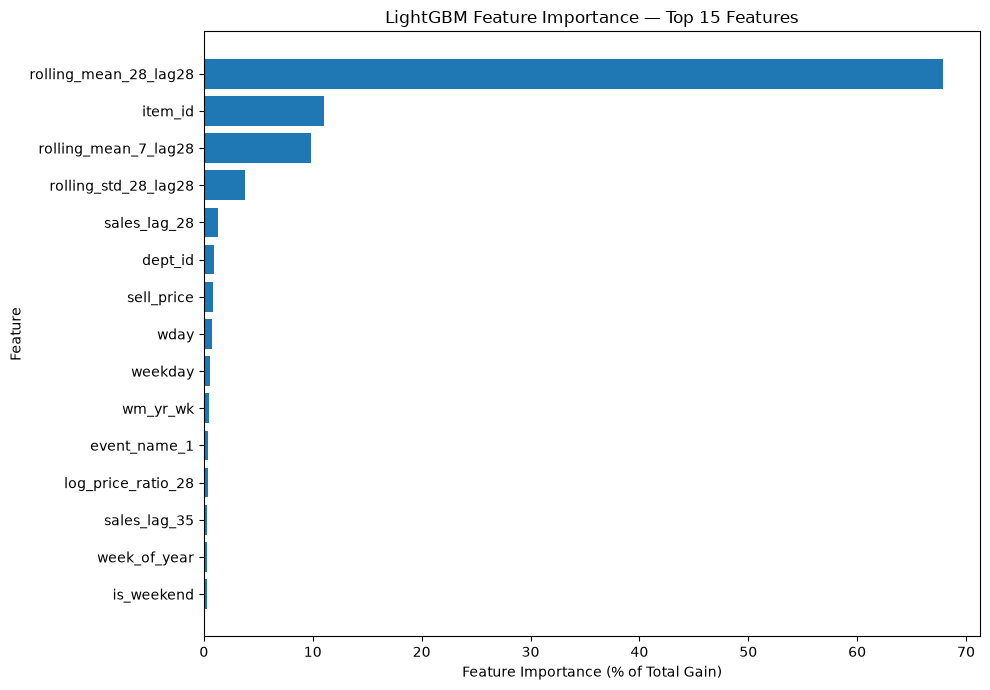

In [28]:
# ---------------------------------------------------------
# Visualize the 15 most important LightGBM features
# ---------------------------------------------------------
# Gain-based importance represents each feature's contribution
# to reducing the model objective across tree splits.
#
# We reverse the ordering for the horizontal bar chart so the
# most important feature appears at the top.

top_features = (
    feature_importance
    .head(15)
    .sort_values(
        "gain_pct",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_features["feature"],
    top_features["gain_pct"]
)

plt.xlabel(
    "Feature Importance (% of Total Gain)"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "LightGBM Feature Importance — Top 15 Features"
)

plt.tight_layout()

plt.show()

In [29]:
# ---------------------------------------------------------
# Create binary demand-occurrence target
# ---------------------------------------------------------
# Stage 1 of the two-stage model will predict whether an
# available product has any sales on a given day.
#
# Target:
#     0 = zero demand
#     1 = positive demand
#
# We create separate targets for training and validation so
# the original continuous sales target remains unchanged.

y_train_binary = (
    y_train > 0
).astype("uint8")

y_validation_binary = (
    y_validation > 0
).astype("uint8")


# ---------------------------------------------------------
# Inspect class distribution
# ---------------------------------------------------------
# Understanding the class balance is important before fitting
# the classifier because it affects how classification metrics
# should be interpreted.

train_class_distribution = (
    y_train_binary
    .value_counts()
    .sort_index()
    .rename(
        index={
            0: "Zero demand",
            1: "Positive demand",
        }
    )
    .to_frame("observations")
)

train_class_distribution["percentage"] = (
    train_class_distribution["observations"]
    / len(y_train_binary)
    * 100
)


print("Training binary target:")
display(train_class_distribution)

print(
    "\nValidation positive-demand rate:",
    f"{y_validation_binary.mean():.2%}"
)

Training binary target:


,observations,percentage
sales,,
Zero demand,2518402,55.472974
Positive demand,2021470,44.527026



Validation positive-demand rate: 46.66%


In [30]:
# ---------------------------------------------------------
# Stage 1: LightGBM demand-occurrence classifier
# ---------------------------------------------------------
# The classifier predicts:
#
#     P(sales > 0)
#
# for each available product-day.
#
# We keep the configuration broadly comparable to the
# regression model so that the main experimental change is
# the binary classification objective.

lgbm_classifier = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    min_child_samples=50,

    # Row sampling is activated every boosting iteration.
    subsample=0.8,
    subsample_freq=1,

    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=0.1,

    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)


# ---------------------------------------------------------
# Train with chronological validation and early stopping
# ---------------------------------------------------------
# Binary log loss is used during training because we want
# well-behaved probability estimates, not just hard classes.
#
# These probabilities will later allow us to choose a demand
# threshold based on forecasting performance.

lgbm_classifier.fit(
    X_train,
    y_train_binary,

    eval_set=[
        (X_validation, y_validation_binary)
    ],

    eval_metric="binary_logloss",

    categorical_feature=categorical_features,

    callbacks=[
        lgb.early_stopping(
            stopping_rounds=50,
            verbose=True
        ),
        lgb.log_evaluation(
            period=50
        ),
    ],
)


print(
    "\nBest iteration:",
    lgbm_classifier.best_iteration_
)

print(
    "Best validation score:",
    lgbm_classifier.best_score_
)

C:\Users\saman\OneDrive\Desktop\Projects\retail-demand-intelligence\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


Training until validation scores don't improve for 50 rounds
[50]	valid_0's binary_logloss: 0.552123
[100]	valid_0's binary_logloss: 0.54665
[150]	valid_0's binary_logloss: 0.546084
[200]	valid_0's binary_logloss: 0.546183
Early stopping, best iteration is:
[161]	valid_0's binary_logloss: 0.545832

Best iteration: 161
Best validation score: defaultdict(<class 'collections.OrderedDict'>, {'valid_0': OrderedDict({'binary_logloss': np.float64(0.5458317446041463)})})


In [31]:
# ---------------------------------------------------------
# Generate validation probabilities
# ---------------------------------------------------------
# predict_proba() returns probabilities for both classes.
# Column 1 is the estimated probability that sales > 0.
#
# We keep the probabilities because later we will test
# different probability thresholds for the final forecast.

positive_demand_probability = (
    lgbm_classifier.predict_proba(
        X_validation,
        num_iteration=lgbm_classifier.best_iteration_
    )[:, 1]
)


# ---------------------------------------------------------
# Convert probabilities into initial binary predictions
# ---------------------------------------------------------
# 0.50 is used only as the initial classification threshold.
# We will NOT assume that 0.50 is necessarily the best
# threshold for minimizing demand-forecasting error.

classification_threshold = 0.50

binary_predictions = (
    positive_demand_probability
    >= classification_threshold
).astype("uint8")


# ---------------------------------------------------------
# Import classification evaluation metrics
# ---------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)


# ---------------------------------------------------------
# Calculate validation classification metrics
# ---------------------------------------------------------

classifier_accuracy = accuracy_score(
    y_validation_binary,
    binary_predictions
)

classifier_precision = precision_score(
    y_validation_binary,
    binary_predictions
)

classifier_recall = recall_score(
    y_validation_binary,
    binary_predictions
)

classifier_f1 = f1_score(
    y_validation_binary,
    binary_predictions
)

classifier_roc_auc = roc_auc_score(
    y_validation_binary,
    positive_demand_probability
)


print("Demand-Occurrence Classifier")
print(f"Threshold: {classification_threshold:.2f}")
print(f"Accuracy:  {classifier_accuracy:.4f}")
print(f"Precision: {classifier_precision:.4f}")
print(f"Recall:    {classifier_recall:.4f}")
print(f"F1 score:  {classifier_f1:.4f}")
print(f"ROC-AUC:   {classifier_roc_auc:.4f}")


# ---------------------------------------------------------
# Confusion matrix
# ---------------------------------------------------------
# Matrix layout:
#
#                  Predicted
#                 Zero  Positive
# Actual Zero      TN      FP
# Actual Positive  FN      TP

conf_matrix = confusion_matrix(
    y_validation_binary,
    binary_predictions
)

print("\nConfusion Matrix:")
print(conf_matrix)

Demand-Occurrence Classifier
Threshold: 0.50
Accuracy:  0.7213
Precision: 0.7237
Recall:    0.6515
F1 score:  0.6857
ROC-AUC:   0.7942

Confusion Matrix:
[[35623  9911]
 [13884 25954]]


In [32]:
# ---------------------------------------------------------
# Evaluate two-stage forecasts across probability thresholds
# ---------------------------------------------------------
# The classifier determines whether demand is likely to occur.
#
# If P(sales > 0) is below the threshold:
#     forecast = 0
#
# Otherwise:
#     forecast = existing LightGBM Poisson prediction
#
# Threshold selection is based only on the validation period.
# The final test period remains untouched.

thresholds = np.arange(
    0.10,
    0.81,
    0.05
)

threshold_results = []


for threshold in thresholds:

    # Apply the demand-occurrence gate to the existing
    # Poisson demand predictions.
    two_stage_prediction = np.where(
        positive_demand_probability >= threshold,
        lgbm_predicted,
        0.0
    )


    # Calculate forecast errors.
    errors = (
        lgbm_actual
        - two_stage_prediction
    )

    absolute_errors = np.abs(
        errors
    )


    # Calculate the same metrics used for all previous models.
    threshold_mae = absolute_errors.mean()

    threshold_rmse = np.sqrt(
        np.mean(
            errors ** 2
        )
    )

    threshold_wmape = (
        absolute_errors.sum()
        / lgbm_actual.sum()
    )


    # Track how frequently the classifier suppresses the
    # Poisson forecast to exactly zero.
    zero_forecast_rate = (
        two_stage_prediction == 0
    ).mean()


    threshold_results.append(
        {
            "threshold": threshold,
            "MAE": threshold_mae,
            "RMSE": threshold_rmse,
            "WMAPE": threshold_wmape,
            "zero_forecast_rate": zero_forecast_rate,
        }
    )


threshold_results = pd.DataFrame(
    threshold_results
)


# ---------------------------------------------------------
# Identify threshold with lowest validation WMAPE
# ---------------------------------------------------------
# On a fixed validation set, minimizing WMAPE is equivalent
# to minimizing total absolute error because the denominator
# (total actual sales) is constant.

best_threshold_result = (
    threshold_results
    .sort_values("WMAPE")
    .head(1)
)


# Format a display copy without changing the numerical data
# needed for subsequent modeling.
threshold_results_display = (
    threshold_results.copy()
)

threshold_results_display["WMAPE"] = (
    threshold_results_display["WMAPE"]
    .map(lambda x: f"{x:.2%}")
)

threshold_results_display["zero_forecast_rate"] = (
    threshold_results_display["zero_forecast_rate"]
    .map(lambda x: f"{x:.2%}")
)


display(
    threshold_results_display
)

print("\nBest threshold based on validation WMAPE:")

display(
    best_threshold_result
)

,threshold,MAE,RMSE,WMAPE,zero_forecast_rate
0,0.10,1.104920,2.137491,73.72%,6.21%
1,0.15,1.097105,2.138969,73.20%,12.76%
2,0.20,1.086573,2.140366,72.50%,19.47%
3,0.25,1.073103,2.142327,71.60%,26.18%
4,0.30,1.060452,2.149428,70.75%,32.91%
5,0.35,1.049521,2.157802,70.02%,39.52%
6,0.40,1.040604,2.166228,69.43%,45.96%
7,0.45,1.034761,2.177495,69.04%,52.22%
8,0.50,1.031789,2.187380,68.84%,57.99%
9,0.55,1.035745,2.222788,69.11%,63.76%



Best threshold based on validation WMAPE:


,threshold,MAE,RMSE,WMAPE,zero_forecast_rate
8,0.5,1.031789,2.18738,0.688413,0.579897


In [33]:
# ---------------------------------------------------------
# Fine-grained threshold search around coarse optimum
# ---------------------------------------------------------
# The coarse search identified 0.50 as the best threshold.
# We now search from 0.40 to 0.60 in increments of 0.01
# before fixing the validation-selected threshold.

fine_thresholds = np.arange(
    0.40,
    0.601,
    0.01
)

fine_threshold_results = []


for threshold in fine_thresholds:

    # Gate the Poisson forecast using the classifier's
    # estimated probability of positive demand.
    prediction = np.where(
        positive_demand_probability >= threshold,
        lgbm_predicted,
        0.0
    )

    errors = (
        lgbm_actual
        - prediction
    )

    absolute_errors = np.abs(
        errors
    )


    fine_threshold_results.append(
        {
            "threshold": threshold,

            "MAE": absolute_errors.mean(),

            "RMSE": np.sqrt(
                np.mean(errors ** 2)
            ),

            "WMAPE": (
                absolute_errors.sum()
                / lgbm_actual.sum()
            ),

            "zero_forecast_rate": (
                prediction == 0
            ).mean(),
        }
    )


fine_threshold_results = pd.DataFrame(
    fine_threshold_results
)


# Floating-point ranges can produce values such as
# 0.5000000000000001, so round thresholds for readability.
fine_threshold_results["threshold"] = (
    fine_threshold_results["threshold"]
    .round(2)
)


# Select the threshold that minimizes validation WMAPE.
best_fine_threshold = (
    fine_threshold_results
    .sort_values("WMAPE")
    .iloc[0]
)


print("Best fine-grained threshold:")
print(
    f"Threshold: {best_fine_threshold['threshold']:.2f}"
)
print(
    f"MAE:       {best_fine_threshold['MAE']:.4f}"
)
print(
    f"RMSE:      {best_fine_threshold['RMSE']:.4f}"
)
print(
    f"WMAPE:     {best_fine_threshold['WMAPE']:.2%}"
)
print(
    "Zero forecast rate:",
    f"{best_fine_threshold['zero_forecast_rate']:.2%}"
)

Best fine-grained threshold:
Threshold: 0.50
MAE:       1.0318
RMSE:      2.1874
WMAPE:     68.84%
Zero forecast rate: 57.99%


In [34]:
# ---------------------------------------------------------
# Freeze validation-selected model configuration
# ---------------------------------------------------------
# The probability threshold was selected exclusively using
# the validation period.
#
# From this point onward, the threshold must remain fixed.
# The test set must NOT be used for further threshold tuning.

SELECTED_THRESHOLD = 0.50

SELECTED_MODEL = (
    "Two-stage LightGBM "
    "(binary classifier + Poisson regressor)"
)


print(
    "Selected model:",
    SELECTED_MODEL
)

print(
    "Selected threshold:",
    f"{SELECTED_THRESHOLD:.2f}"
)

print(
    "Validation WMAPE:",
    f"{best_fine_threshold['WMAPE']:.2%}"
)

Selected model: Two-stage LightGBM (binary classifier + Poisson regressor)
Selected threshold: 0.50
Validation WMAPE: 68.84%


In [35]:
# ---------------------------------------------------------
# Prepare untouched test feature matrix
# ---------------------------------------------------------
# The test set represents the final 28-day out-of-sample
# evaluation period.
#
# We use exactly the same features and transformations that
# were used for training and validation. No model-selection
# decisions will be made using this test set.


# Create the test feature matrix using the previously defined
# LightGBM feature list (which excludes is_available).
X_test = (
    test_df[ml_features]
    .copy()
)

y_test = (
    test_df["sales"]
    .astype("float32")
    .copy()
)


# ---------------------------------------------------------
# Align categorical feature levels with training
# ---------------------------------------------------------
# LightGBM requires categorical variables to use compatible
# category definitions across training and prediction data.
#
# We therefore reuse the category levels learned from X_train
# rather than allowing pandas to independently infer them.

for column in categorical_features:

    X_test[column] = pd.Categorical(
        X_test[column],
        categories=X_train[column].cat.categories
    )


# ---------------------------------------------------------
# Validate the final test matrix
# ---------------------------------------------------------

print(
    "X_test shape:",
    X_test.shape
)

print(
    "y_test shape:",
    y_test.shape
)

print(
    "Missing X_test values:",
    int(
        X_test.isna().sum().sum()
    )
)

print(
    "Missing y_test values:",
    int(
        y_test.isna().sum()
    )
)

print(
    "Test start:",
    test_df["date"].min()
)

print(
    "Test end:",
    test_df["date"].max()
)

print(
    "Unique test days:",
    test_df["date"].nunique()
)

print(
    "Unique test products:",
    test_df["item_id"].nunique()
)

X_test shape: (85372, 30)
y_test shape: (85372,)
Missing X_test values: 0
Missing y_test values: 0
Test start: 2016-04-25 00:00:00
Test end: 2016-05-22 00:00:00
Unique test days: 28
Unique test products: 3049


In [36]:
# ---------------------------------------------------------
# Generate final test predictions
# ---------------------------------------------------------
# Both models and the classification threshold were selected
# using training/validation data only.
#
# The test set is now used strictly for final out-of-sample
# evaluation.


# Stage 1:
# Estimate the probability that each product-day will have
# positive demand.
test_positive_probability = (
    lgbm_classifier.predict_proba(
        X_test,
        num_iteration=lgbm_classifier.best_iteration_
    )[:, 1]
)


# Stage 2:
# Estimate demand magnitude using the Poisson regression model.
test_poisson_prediction = (
    lgbm_model.predict(
        X_test,
        num_iteration=lgbm_model.best_iteration_
    )
)


# Demand cannot be negative, so retain the same safeguard
# used during validation.
test_poisson_prediction = np.clip(
    test_poisson_prediction,
    a_min=0,
    a_max=None
)


# ---------------------------------------------------------
# Apply frozen demand-occurrence threshold
# ---------------------------------------------------------
# If the classifier estimates P(sales > 0) below 0.50,
# forecast zero.
#
# Otherwise retain the Poisson demand forecast.
#
# IMPORTANT:
# SELECTED_THRESHOLD was fixed using validation data and is
# not changed based on test performance.

test_two_stage_prediction = np.where(
    test_positive_probability >= SELECTED_THRESHOLD,
    test_poisson_prediction,
    0.0
)


# ---------------------------------------------------------
# Prediction integrity checks
# ---------------------------------------------------------

print(
    "Test predictions:",
    f"{len(test_two_stage_prediction):,}"
)

print(
    "Missing predictions:",
    int(
        np.isnan(
            test_two_stage_prediction
        ).sum()
    )
)

print(
    "Minimum prediction:",
    f"{test_two_stage_prediction.min():.4f}"
)

print(
    "Maximum prediction:",
    f"{test_two_stage_prediction.max():.4f}"
)

print(
    "Mean prediction:",
    f"{test_two_stage_prediction.mean():.4f}"
)

print(
    "Actual mean sales:",
    f"{y_test.mean():.4f}"
)

print(
    "Zero forecast rate:",
    f"{(test_two_stage_prediction == 0).mean():.2%}"
)

Test predictions: 85,372
Missing predictions: 0
Minimum prediction: 0.0000
Maximum prediction: 99.2675
Mean prediction: 1.2534
Actual mean sales: 1.5700
Zero forecast rate: 58.12%


In [37]:
# ---------------------------------------------------------
# Final out-of-sample test evaluation
# ---------------------------------------------------------
# The test set has not been used for feature selection,
# hyperparameter tuning, or threshold selection.
#
# These metrics therefore represent the final evaluation of
# the frozen two-stage forecasting system.

test_actual = (
    y_test
    .astype("float64")
    .to_numpy()
)

test_predicted = (
    test_two_stage_prediction
    .astype("float64")
)


# Calculate forecast errors.
test_errors = (
    test_actual
    - test_predicted
)

test_absolute_errors = np.abs(
    test_errors
)


# Mean Absolute Error
test_mae = (
    test_absolute_errors.mean()
)


# Root Mean Squared Error
test_rmse = np.sqrt(
    np.mean(
        test_errors ** 2
    )
)


# Weighted Mean Absolute Percentage Error
test_wmape = (
    test_absolute_errors.sum()
    / test_actual.sum()
)


# Forecast bias
# Positive = aggregate overprediction.
# Negative = aggregate underprediction.
test_forecast_bias = (
    test_predicted.sum()
    - test_actual.sum()
)

test_forecast_bias_pct = (
    test_forecast_bias
    / test_actual.sum()
    * 100
)


print("Final Two-Stage LightGBM — Test Set")
print(f"MAE:   {test_mae:.4f}")
print(f"RMSE:  {test_rmse:.4f}")
print(f"WMAPE: {test_wmape:.2%}")
print(
    f"Forecast bias: {test_forecast_bias:,.0f}"
)
print(
    f"Forecast bias (%): {test_forecast_bias_pct:.2f}%"
)

Final Two-Stage LightGBM — Test Set
MAE:   1.1025
RMSE:  2.3300
WMAPE: 70.22%
Forecast bias: -27,023
Forecast bias (%): -20.16%


In [38]:
# ---------------------------------------------------------
# Compare all forecasting approaches on the final test set
# ---------------------------------------------------------
# All models are evaluated against exactly the same 85,372
# test observations.
#
# Importantly, no test results are used to modify the models
# or the previously selected 0.50 threshold.


def calculate_forecast_metrics(actual, prediction):
    """
    Calculate the forecasting metrics used consistently
    throughout the project.

    Returns MAE, RMSE, WMAPE, and aggregate forecast bias.
    """

    actual = np.asarray(
        actual,
        dtype="float64"
    )

    prediction = np.asarray(
        prediction,
        dtype="float64"
    )

    errors = (
        actual
        - prediction
    )

    absolute_errors = np.abs(
        errors
    )

    mae = absolute_errors.mean()

    rmse = np.sqrt(
        np.mean(errors ** 2)
    )

    wmape = (
        absolute_errors.sum()
        / actual.sum()
    )

    # Positive bias means overforecasting;
    # negative bias means underforecasting.
    bias_pct = (
        (
            prediction.sum()
            - actual.sum()
        )
        / actual.sum()
        * 100
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "WMAPE": wmape,
        "Bias (%)": bias_pct,
    }


# ---------------------------------------------------------
# 1. Seasonal-naive test forecast
# ---------------------------------------------------------
# Predict each product's test-period demand using its sales
# observed exactly 28 days earlier.

test_baseline_prediction = (
    test_df["sales_lag_28"]
    .astype("float64")
    .to_numpy()
)


# Apply the deterministic availability rule.
# An unavailable product cannot generate sales.
test_availability = (
    test_df["is_available"]
    .to_numpy()
)

test_baseline_prediction = np.where(
    test_availability == 1,
    test_baseline_prediction,
    0.0
)


# ---------------------------------------------------------
# 2. Standalone Poisson forecast
# ---------------------------------------------------------
# These predictions were generated by the frozen regression
# model before applying the occurrence classifier.

test_poisson_final = np.where(
    test_availability == 1,
    test_poisson_prediction,
    0.0
)


# ---------------------------------------------------------
# 3. Frozen two-stage forecast
# ---------------------------------------------------------

test_two_stage_final = np.where(
    test_availability == 1,
    test_two_stage_prediction,
    0.0
)


# ---------------------------------------------------------
# Calculate comparable metrics
# ---------------------------------------------------------

test_model_comparison = pd.DataFrame(
    {
        "Seasonal Naive": calculate_forecast_metrics(
            test_actual,
            test_baseline_prediction
        ),

        "LightGBM Poisson": calculate_forecast_metrics(
            test_actual,
            test_poisson_final
        ),

        "Two-Stage LightGBM": calculate_forecast_metrics(
            test_actual,
            test_two_stage_final
        ),
    }
).T


# Keep numerical results intact for later calculations.
test_model_comparison

,MAE,RMSE,WMAPE,Bias (%)
Seasonal Naive,1.410216,2.935737,0.898241,-4.533992
LightGBM Poisson,1.160518,2.263935,0.739195,-2.947797
Two-Stage LightGBM,1.102465,2.330025,0.702218,-20.161786


In [39]:
# ---------------------------------------------------------
# Quantify final out-of-sample improvement
# ---------------------------------------------------------
# Improvements are measured relative to the seasonal-naive
# benchmark on the same untouched 28-day test period.

baseline_test = (
    test_model_comparison
    .loc["Seasonal Naive"]
)

poisson_test = (
    test_model_comparison
    .loc["LightGBM Poisson"]
)

two_stage_test = (
    test_model_comparison
    .loc["Two-Stage LightGBM"]
)


def percentage_error_reduction(
    baseline_value,
    model_value
):
    """
    Calculate percentage reduction in an error metric
    relative to the seasonal-naive benchmark.
    """

    return (
        (baseline_value - model_value)
        / baseline_value
        * 100
    )


final_improvement = pd.DataFrame(
    {
        "Model": [
            "LightGBM Poisson",
            "Two-Stage LightGBM",
        ],

        "MAE Improvement (%)": [
            percentage_error_reduction(
                baseline_test["MAE"],
                poisson_test["MAE"]
            ),
            percentage_error_reduction(
                baseline_test["MAE"],
                two_stage_test["MAE"]
            ),
        ],

        "RMSE Improvement (%)": [
            percentage_error_reduction(
                baseline_test["RMSE"],
                poisson_test["RMSE"]
            ),
            percentage_error_reduction(
                baseline_test["RMSE"],
                two_stage_test["RMSE"]
            ),
        ],

        "WMAPE Improvement (%)": [
            percentage_error_reduction(
                baseline_test["WMAPE"],
                poisson_test["WMAPE"]
            ),
            percentage_error_reduction(
                baseline_test["WMAPE"],
                two_stage_test["WMAPE"]
            ),
        ],
    }
)


final_improvement.round(2)

,Model,MAE Improvement (%),RMSE Improvement (%),WMAPE Improvement (%)
0,LightGBM Poisson,17.71,22.88,17.71
1,Two-Stage LightGBM,21.82,20.63,21.82


## Final Model Evaluation

Three forecasting approaches were evaluated on an untouched 28-day test
period containing 85,372 product-day observations across 3,049 products.

| Model | MAE | RMSE | WMAPE | Forecast Bias |
|---|---:|---:|---:|---:|
| Seasonal Naive (Lag 28) | 1.4102 | 2.9357 | 89.82% | -4.53% |
| LightGBM Poisson | 1.1605 | **2.2639** | 73.92% | **-2.95%** |
| Two-Stage LightGBM | **1.1025** | 2.3300 | **70.22%** | -20.16% |

### Out-of-Sample Improvement

Relative to the seasonal-naive benchmark:

- LightGBM Poisson reduced MAE and WMAPE by **17.71%** and RMSE by
  **22.88%**.
- The two-stage LightGBM model reduced MAE and WMAPE by **21.82%** and
  RMSE by **20.63%**.

### Interpretation

The standalone LightGBM Poisson model substantially improved forecasting
performance over the seasonal-naive benchmark while maintaining relatively
low aggregate forecast bias.

Analysis of validation errors showed that the Poisson model performed
particularly well on positive-demand observations but was less effective
on zero-demand product-days. To address this intermittent-demand behavior,
a two-stage forecasting architecture was evaluated.

The first stage used a LightGBM binary classifier to estimate the probability
of positive demand. The second stage used the existing Poisson regression
forecast for observations classified as positive demand. A probability
threshold of **0.50** was selected exclusively on the validation period and
then frozen before test evaluation.

The two-stage architecture achieved the lowest test MAE and WMAPE, indicating
better typical product-day forecast accuracy. However, its RMSE was slightly
higher than the standalone Poisson model and it produced a substantial
**-20.16% aggregate forecast bias**. This indicates that suppressing forecasts
for likely zero-demand observations improved absolute error but occasionally
removed genuine positive demand, resulting in systematic underforecasting.

Therefore, there is no universally superior model across all business
objectives:

- the **two-stage model** is preferred when minimizing item-day absolute
  forecasting error is the primary objective;
- the **standalone Poisson model** is preferable when controlling large
  forecast errors and maintaining aggregate demand calibration are more
  important.

This illustrates an important practical forecasting principle: model
selection should reflect the operational cost of forecast errors rather than
relying on a single performance metric.

### Experimental Integrity

All feature engineering used information available at least 28 days before
the forecasted observation, except for target-period variables assumed to be
known in advance, such as calendar information and planned selling prices.

Model selection and the two-stage classification threshold were determined
using the validation period only. The final 28-day test period was kept
untouched until the forecasting architecture and threshold had been fixed.
No model parameters were subsequently adjusted using test performance.